# **Assignment 3**
# Forward Propagation and Backpropagation using TensorFlow/Keras

## Aim
To implement a Multi-Layer Perceptron (MLP) using TensorFlow/Keras on the Wine Dataset and understand how forward propagation and backpropagation work during neural network training.

The assignment also analyzes the effect of different learning rates and the number of training epochs on model performance.
---
# Objectives
- Perform basic data analysis on the Wine Dataset.
- Preprocess the dataset for neural network training.
- Build a Multi-Layer Perceptron (MLP) using TensorFlow/Keras.
- Train the model using forward propagation and backpropagation.
- Experiment with different learning rates.
- Experiment with different numbers of epochs.
- Compare the performance of different models.
- Evaluate the final model using accuracy and loss graphs.
---
# About the Dataset
The Wine Dataset is a well-known classification dataset available in the Scikit-Learn library.
It contains the chemical analysis of wines grown in the same region in Italy but derived from three different cultivars (wine classes).
The goal is to predict the correct wine class based on its chemical properties.
### Dataset Information
- Total Samples: **178**
- Number of Features: **13**
- Number of Classes: **3**
# Workflow
1. Import required libraries.
2. Load the Wine Dataset.
3. Perform Exploratory Data Analysis (EDA).
4. Preprocess the data.
5. Split the dataset into training and testing sets.
6. Standardize the features.
7. Build an MLP using TensorFlow/Keras.
8. Train the model.
9. Analyze forward propagation and backpropagation.
10. Experiment with different learning rates.
11. Experiment with different epochs.
12. Evaluate the model.
13. Draw conclusions.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam
import warnings
warnings.filterwarnings("ignore")
print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# Load the Wine dataset
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
# Add the target column
df['target'] = wine.target
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [ ]:
# Display basic information about the dataset
print("Shape of the dataset:", df.shape)
print("\nFeature Names:")
print(wine.feature_names)
print("\nTarget Classes:")
print(wine.target_names)
print("\nFirst 5 rows of the dataset:")
display(df.head())

Shape of the dataset: (178, 14)

Feature Names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Target Classes:
['class_0' 'class_1' 'class_2']

First 5 rows of the dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [ ]:
# Display information about the dataset
print("Dataset Information:\n")
df.info()
print("\n" + "="*60)
# Check for missing values
print("\nMissing Values in Each Column:\n")
print(df.isnull().sum())
print("\n" + "="*60)
# Display statistical summary
print("\nStatistical Summary:\n")
display(df.describe())

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


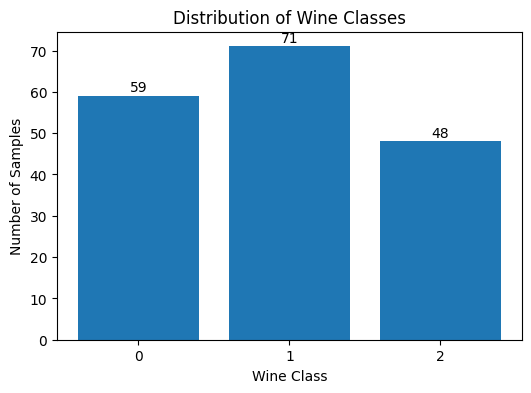

In [ ]:
# Count the number of samples in each class
class_counts = df['target'].value_counts().sort_index()
# Plot the class distribution
plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values)
plt.title("Distribution of Wine Classes")
plt.xlabel("Wine Class")
plt.ylabel("Number of Samples")
plt.xticks(class_counts.index)
# Display the count above each bar.
for i, count in enumerate(class_counts.values):
  plt.text(i, count + 1, str(count), ha='center')
plt.show()

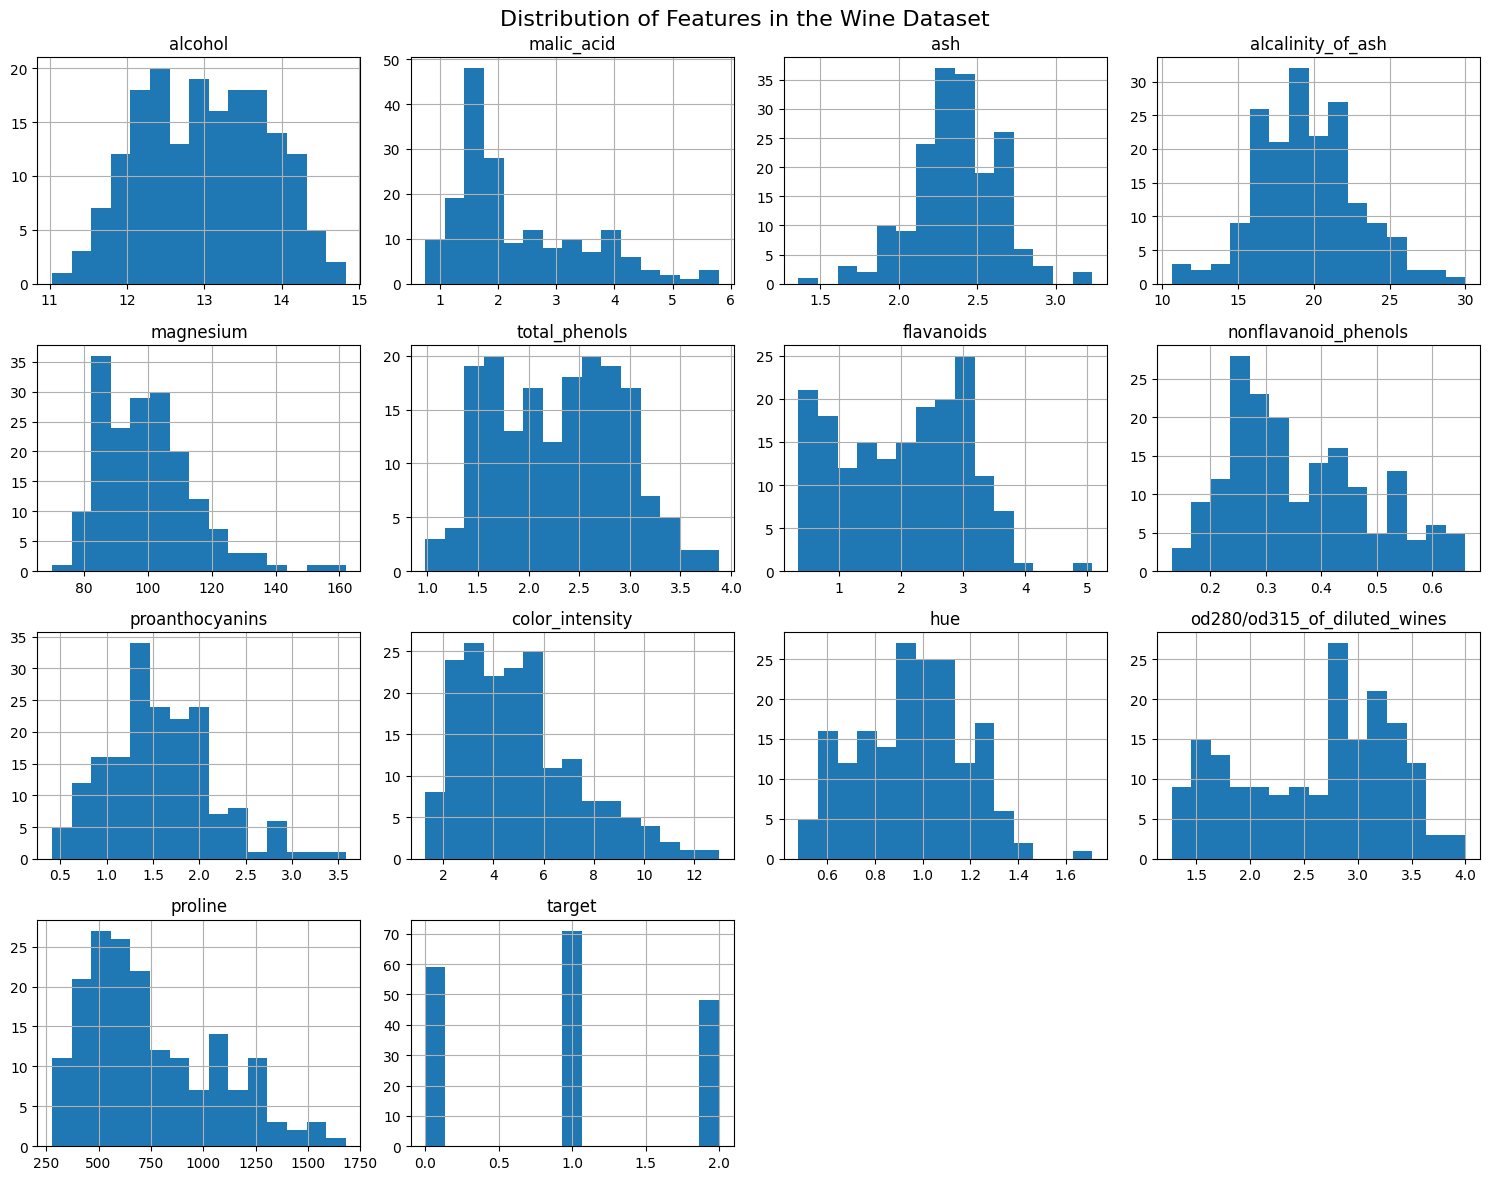

In [ ]:
# Plot histograms for all numerical features
df.hist(figsize=(15, 12), bins=15)
plt.suptitle("Distribution of Features in the Wine Dataset", fontsize=16)
plt.tight_layout()
plt.show()

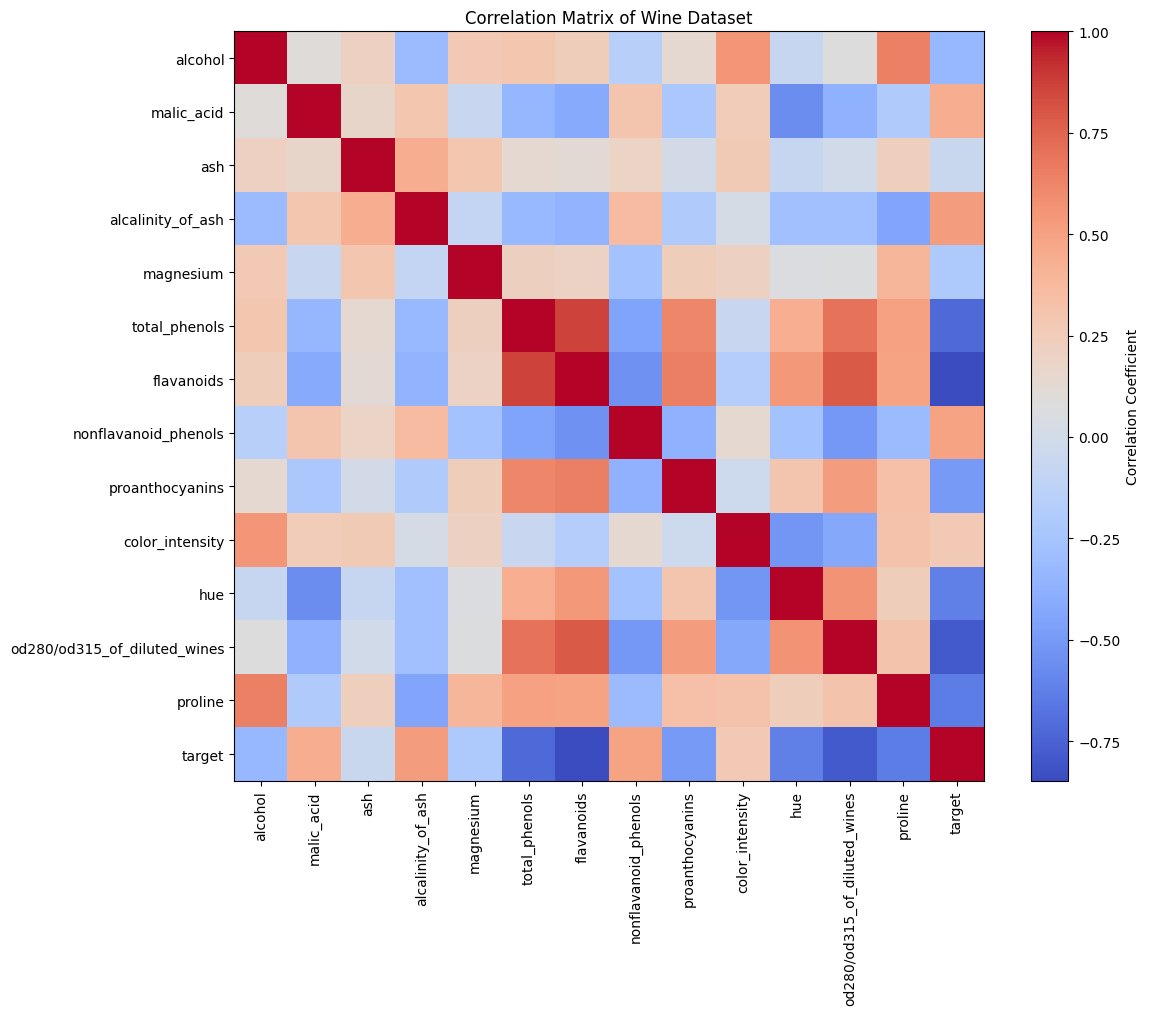

In [ ]:
# Compute the correlation matrix
correlation_matrix = df.corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 10))

plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation Coefficient')

plt.xticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns,
           rotation=90)

plt.yticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns)

plt.title("Correlation Matrix of Wine Dataset")

plt.tight_layout()
plt.show()

In [ ]:
# Separate input features (X) and target variable (y)
X = df.drop('target', axis=1)
y = df['target']
print("Shape of X (Features):", X.shape)
print("Shape of y (Target):", y.shape)
print("\nFirst 5 rows of Features (X):")
display(X.head())
print("\nFirst 5 values of Target (y):")
display(y.head())

Shape of X (Features): (178, 13)
Shape of y (Target): (178,)

First 5 rows of Features (X):


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



First 5 values of Target (y):


,target
0,0
1,0
2,0
3,0
4,0


In [ ]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training Feature Shape :", X_train.shape)
print("Testing Feature Shape  :", X_test.shape)
print("Training Target Shape  :", y_train.shape)
print("Testing Target Shape   :", y_test.shape)

Training Feature Shape : (142, 13)
Testing Feature Shape  : (36, 13)
Training Target Shape  : (142,)
Testing Target Shape   : (36,)


In [ ]:
# Standardize the features using StandardScaler
scaler = StandardScaler()
# Fit the scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)
# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)
print("Training data shape after scaling:", X_train_scaled.shape)
print("Testing data shape after scaling :", X_test_scaled.shape)
print("\nFirst training sample before scaling:")
print(X_train.iloc[0])
print("\nFirst training sample after scaling:")
print(X_train_scaled[0])

Training data shape after scaling: (142, 13)
Testing data shape after scaling : (36, 13)

First training sample before scaling:
alcohol                          13.28
malic_acid                        1.64
ash                               2.84
alcalinity_of_ash                15.50
magnesium                       110.00
total_phenols                     2.60
flavanoids                        2.68
nonflavanoid_phenols              0.34
proanthocyanins                   1.36
color_intensity                   4.60
hue                               1.09
od280/od315_of_diluted_wines      2.78
proline                         880.00
Name: 36, dtype: float64

First training sample after scaling:
[ 0.38580089 -0.63787118  1.77666817 -1.22453161  0.69643032  0.52686525
  0.73229212 -0.1695489  -0.41578344 -0.16746725  0.62437819  0.2529082
  0.46772474]


In [ ]:
# Build the Multi-Layer Perceptron (MLP)

model = Sequential([
    Dense(16, activation='relu', input_shape=(13,)),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

# Display the model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 387 (1.51 KB)

 Trainable params: 387 (1.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the MLP model
optimizer = Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
# Train the MLP model
history = model.fit(
  X_train_scaled,
  y_train,
  validation_data=(X_test_scaled, y_test),
  epochs=50,
  batch_size=16,
  verbose=1
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 0.5563 - loss: 0.9941 - val_accuracy: 0.5833 - val_loss: 0.9248
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5915 - loss: 0.9112 - val_accuracy: 0.6111 - val_loss: 0.8525
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6197 - loss: 0.8429 - val_accuracy: 0.6389 - val_loss: 0.7922
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6338 - loss: 0.7844 - val_accuracy: 0.6389 - val_loss: 0.7387
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6690 - loss: 0.7318 - val_accuracy: 0.6944 - val_loss: 0.6887
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7042 - loss: 0.6803 - val_accuracy: 0.6667 - val_loss: 0.6415
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7394 - loss: 0.6325 - val_accuracy: 0.7500 - val_loss: 0.5972
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7535 - loss: 0.5862 - val_accuracy: 0.8333 - val_loss: 0.5544


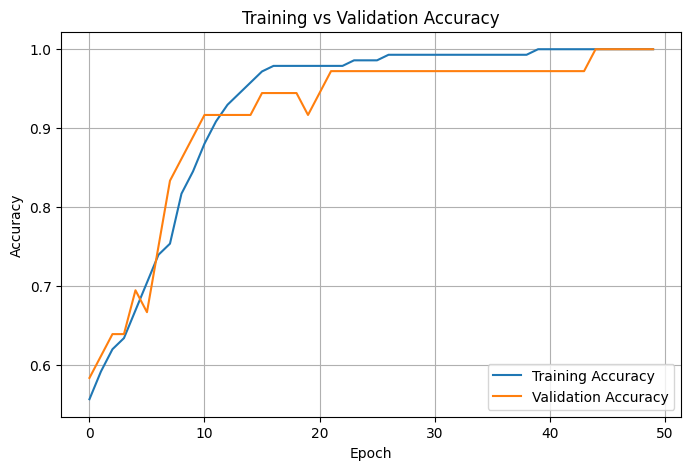

In [ ]:
# Plot Training and Validation Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

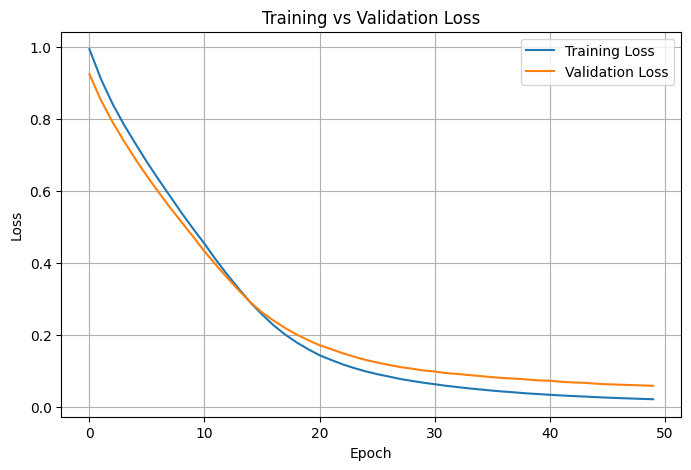

In [ ]:
# Plot Training and Validation Loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Compare different learning rates
learning_rates = [0.1, 0.01, 0.001]
lr_accuracies = []
for lr in learning_rates:
    # Build a new model
    model_lr = Sequential([
        Dense(16, activation='relu', input_shape=(13,)),
        Dense(8, activation='relu'),
        Dense(3, activation='softmax')
    ])
    # Compile the model with the current learning rate
    model_lr.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    # Train the model
    model_lr.fit(
        X_train_scaled,
        y_train,
        epochs=50,
        batch_size=16,
        verbose=0
    )
    # Evaluate on test data
    loss, accuracy = model_lr.evaluate(X_test_scaled, y_test, verbose=0)
    lr_accuracies.append(accuracy)
    print(f"Learning Rate = {lr} --> Test Accuracy = {accuracy:.4f}")

Learning Rate = 0.1 --> Test Accuracy = 1.0000
Learning Rate = 0.01 --> Test Accuracy = 0.9167
Learning Rate = 0.001 --> Test Accuracy = 0.9722


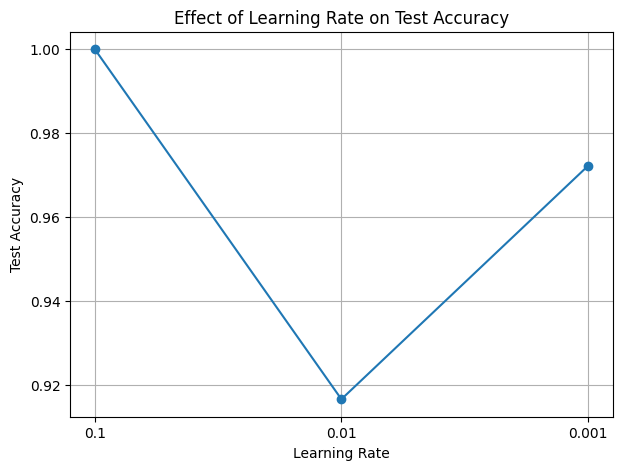

In [ ]:
# Plot learning rate comparison

plt.figure(figsize=(7,5))

plt.plot(
    [str(lr) for lr in learning_rates],
    lr_accuracies,
    marker='o'
)

plt.title("Effect of Learning Rate on Test Accuracy")
plt.xlabel("Learning Rate")
plt.ylabel("Test Accuracy")
plt.grid(True)

plt.show()

In [ ]:
# Compare different numbers of epochs

epoch_values = [20, 50, 100]
epoch_accuracies = []
for epochs in epoch_values:
    # Build a new model
    model_epoch = Sequential([
        Dense(16, activation='relu', input_shape=(13,)),
        Dense(8, activation='relu'),
        Dense(3, activation='softmax')
    ])
    # Compile the model
    model_epoch.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    # Train the model
    model_epoch.fit(
        X_train_scaled,
        y_train,
        epochs=epochs,
        batch_size=16,
        verbose=0
    )
    # Evaluate the model
    loss, accuracy = model_epoch.evaluate(
        X_test_scaled,
        y_test,
        verbose=0
    )
    epoch_accuracies.append(accuracy)
    print(f"Epochs = {epochs} --> Test Accuracy = {accuracy:.4f}")

Epochs = 20 --> Test Accuracy = 0.9444
Epochs = 50 --> Test Accuracy = 0.9722
Epochs = 100 --> Test Accuracy = 0.9444


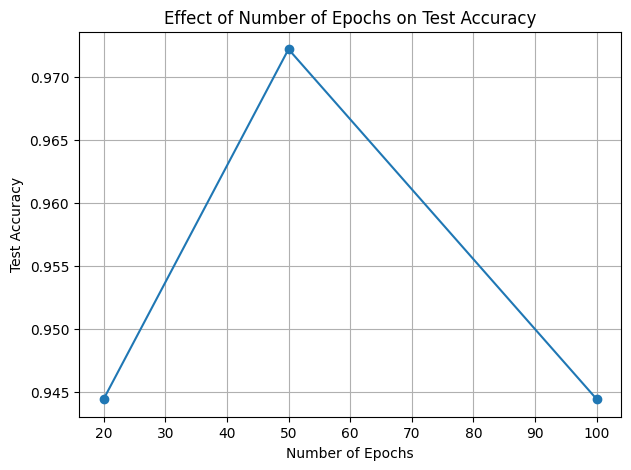

In [ ]:
# Plot effect of epochs on model accuracy

plt.figure(figsize=(7,5))

plt.plot(
    epoch_values,
    epoch_accuracies,
    marker='o'
)

plt.title("Effect of Number of Epochs on Test Accuracy")
plt.xlabel("Number of Epochs")
plt.ylabel("Test Accuracy")

plt.grid(True)

plt.show()

In [ ]:
# Predict the first 5 test samples

predictions = model.predict(X_test_scaled[:5])

predicted_classes = np.argmax(predictions, axis=1)

print("Predicted Classes :", predicted_classes)
print("Actual Classes    :", y_test.values[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
Predicted Classes : [0 2 0 1 1]
Actual Classes    : [0 2 0 1 1]


In [ ]:
# Predict the test data using the trained model
y_pred_prob = model.predict(X_test_scaled)
# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)
print("Prediction completed successfully!")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step 
Prediction completed successfully!


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Model Evaluation Metrics")
print("-" * 30)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Model Evaluation Metrics
------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
